Name: Anzal Azam Shaikh

ID no: DHC-1338

LINK TO ACCESS: https://colab.research.google.com/drive/1eNl8sFVRWv-SdOy7rU3x7OhNnIejz048?usp=sharing

Objective:

Use historical stock data to predict the next day&#39;s closing price.

In [2]:
# Install & Import Libraries
!pip install yfinance scikit-learn pandas matplotlib

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [5]:
# Load Dataset (Yahoo Finance)
# Tesla (you can change to AAPL, GOOGL etc.)

df = yf.download("TSLA", start="2020-01-01", end="2025-01-01")
df.head()

/tmp/ipykernel_3175/3971775370.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("TSLA", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [8]:
# Data Exploration
print(df.shape)
df.info()
df.describe()

(1257, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Open, TSLA)    1257 non-null   float64
 1   (High, TSLA)    1257 non-null   float64
 2   (Low, TSLA)     1257 non-null   float64
 3   (Close, TSLA)   1257 non-null   float64
 4   (Volume, TSLA)  1257 non-null   int64  
 5   (Target, )      1257 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 68.7 KB


Price,Open,High,Low,Close,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03,1257.000000
mean,213.315219,218.117130,208.204688,213.279443,1.255755e+08,213.577896
std,83.449250,85.225296,81.382769,83.321515,8.211007e+07,83.331672
min,24.980000,26.990667,23.367332,24.081333,2.940180e+07,24.081333
25%,173.889999,177.190002,170.009995,173.860001,7.600980e+07,173.949997
50%,220.916672,225.339996,215.330002,220.190002,1.019936e+08,220.250000
75%,259.209991,264.896667,254.210007,259.670013,1.454174e+08,260.019989
max,475.899994,488.540009,457.510010,479.859985,9.140820e+08,479.859985


In [9]:
# Preprocessing
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df['Target'] = df['Close'].shift(-1)

df = df.dropna()
df.head()

Price,Open,High,Low,Close,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2020-01-02,28.299999,28.713333,28.114000,28.684000,142981500,29.534000
2020-01-03,29.366667,30.266666,29.128000,29.534000,266677500,30.102667
2020-01-06,29.364668,30.104000,29.333332,30.102667,151995000,31.270666
2020-01-07,30.760000,31.441999,30.224001,31.270666,268231500,32.809334
2020-01-08,31.580000,33.232666,31.215334,32.809334,467164500,32.089333


In [10]:
# Features & Target Split
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Target']

In [11]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Model Training (Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
# Prediction
y_pred = model.predict(X_test)

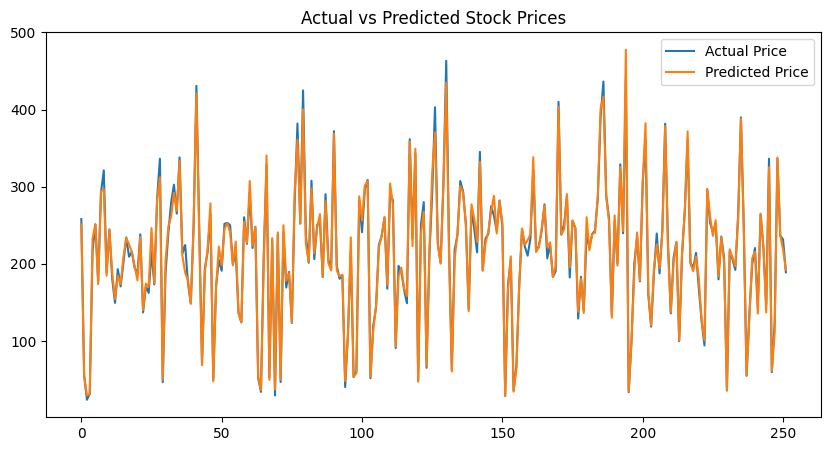

In [14]:
# Visualization
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.show()

In [15]:
# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 6.2103175509188455
RMSE: 9.11696848426803


Conclusion:
- Stock price data was fetched using Yahoo Finance API.
- Linear Regression model was used for prediction.
- The model shows trend-based prediction but is not perfectly accurate due to market volatility.
- Evaluation metrics (MAE and RMSE) were used to measure performance.